# Preface

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
import umap
import magic

plt.style.use("seaborn-v0_8")
sns.set_context("talk")
pd.set_option("display.max_columns", 50)

DATA_ROOT = Path(
    "/Users/tosaka/Developments/AI3073-Bioinfo/Lab/Lab5/docs/data")
DATASETS = {
    "Mouse retina": "data1_mouse_retina",
    "mESC": "data2_mesc",
    "Embryo cortex": "data3_embryo_cortex",
}
RANDOM_STATE = 42

# Data Preprocessing

## Load Dataset

In [2]:
def load_dataset(folder_name: str):
    folder = DATA_ROOT / folder_name
    expr = pd.read_csv(
        folder / "Gene_expression_table_filtered.txt", sep="\t", index_col=0)
    labels = pd.read_csv(
        folder / "sample_cluster_ref_filtered.txt",
        sep=None,
        engine="python",
        header=None,
        names=["cell_id", "cluster"],
    )
    labels["cluster"] = labels["cluster"].astype("category")
    common_cells = expr.columns.intersection(labels["cell_id"])
    expr = expr.loc[:, common_cells]
    labels = labels.set_index("cell_id").loc[common_cells, "cluster"]
    return expr, labels

## Filtering

In [3]:
def preprocess_expression(expr: pd.DataFrame, min_genes: int = 200, min_cells: int = 3) -> pd.DataFrame:
    gene_filter = (expr > 0).sum(axis=1) >= min_cells
    expr = expr.loc[gene_filter]
    cell_filter = (expr > 0).sum(axis=0) >= min_genes
    expr = expr.loc[:, cell_filter]
    return expr

## Normalization

In [4]:
def normalize_expression(expr: pd.DataFrame) -> pd.DataFrame:
    lib_size = expr.sum(axis=0)
    valid = lib_size > 0
    expr = expr.loc[:, valid]
    lib_size = lib_size[valid]
    normalized = expr / lib_size * 1e4
    return np.log1p(normalized)

# Imputation

In [5]:
def run_magic_imputation(cell_df: pd.DataFrame) -> pd.DataFrame:
    magic_op = magic.MAGIC(random_state=RANDOM_STATE)
    imputed = magic_op.fit_transform(cell_df)
    return pd.DataFrame(imputed, index=cell_df.index, columns=cell_df.columns)

# t-SNE

In [6]:
def compute_tsne(matrix: np.ndarray, random_state: int = RANDOM_STATE) -> np.ndarray:
    n_samples = matrix.shape[0]
    if n_samples < 3:
        return np.zeros((n_samples, 2))

    perplexity = min(30, max(5, n_samples // 50))
    perplexity = min(perplexity, n_samples - 1)

    tsne = TSNE(
        n_components=2,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
    )
    return tsne.fit_transform(matrix)

# Dimension Reduction

In [7]:
def compute_embeddings(cell_df: pd.DataFrame, n_pcs: int = 50):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(cell_df)
    max_pcs = min(n_pcs, scaled.shape[1] - 1, scaled.shape[0] - 1)
    n_components = max(2, max_pcs)
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    pcs = pca.fit_transform(scaled)
    reducer = umap.UMAP(random_state=RANDOM_STATE,
                        min_dist=0.3, n_neighbors=30)
    umap_embedding = reducer.fit_transform(pcs)
    return {"scaled": scaled, "pca": pcs, "umap": umap_embedding, "pca_model": pca}


def evaluate_clustering(embedding: np.ndarray, labels: pd.Series, n_clusters: int):
    y_true = labels.astype("category").cat.codes
    results = []

    kmeans = KMeans(n_clusters=n_clusters,
                    random_state=RANDOM_STATE, n_init=20)
    k_pred = kmeans.fit_predict(embedding)
    results.append({"method": "KMeans (Euclidean)",
                   "ari": adjusted_rand_score(y_true, k_pred)})

    agg_euclid = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    agg_pred = agg_euclid.fit_predict(embedding)
    results.append({"method": "Hierarchical-Ward (Euclidean)",
                   "ari": adjusted_rand_score(y_true, agg_pred)})

    agg_cos = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage="average",
        metric="cosine",
    )
    agg_cos_pred = agg_cos.fit_predict(embedding)
    results.append({"method": "Hierarchical-Average (Cosine)",
                   "ari": adjusted_rand_score(y_true, agg_cos_pred)})

    return results

# Result Comparing

In [8]:
all_outputs = {}
ari_rows = []
tsne_records = []

for dataset_name, folder in DATASETS.items():
    expr, labels = load_dataset(folder)
    expr = preprocess_expression(expr)
    labels = labels.loc[expr.columns]

    normalized = normalize_expression(expr)
    cell_matrix = normalized.T  # cells × genes

    tsne_before = compute_tsne(cell_matrix.values)
    imputed = run_magic_imputation(cell_matrix)
    tsne_after = compute_tsne(imputed.values)

    embeddings = compute_embeddings(imputed)
    aligned_labels = labels.loc[imputed.index]
    n_clusters = aligned_labels.nunique()

    cluster_stats = evaluate_clustering(
        embeddings["pca"], aligned_labels, n_clusters)
    for stat in cluster_stats:
        ari_rows.append({"dataset": dataset_name, **stat})

    tsne_records.append(
        pd.DataFrame(
            {
                "TSNE1": tsne_before[:, 0],
                "TSNE2": tsne_before[:, 1],
                "cluster": aligned_labels.values,
                "dataset": dataset_name,
                "stage": "Before MAGIC",
            }
        )
    )
    tsne_records.append(
        pd.DataFrame(
            {
                "TSNE1": tsne_after[:, 0],
                "TSNE2": tsne_after[:, 1],
                "cluster": aligned_labels.values,
                "dataset": dataset_name,
                "stage": "After MAGIC",
            }
        )
    )

    all_outputs[dataset_name] = {
        "labels": aligned_labels,
        "normalized": normalized,
        "tsne_before": tsne_before,
        "tsne_after": tsne_after,
        "imputed": imputed,
        "embeddings": embeddings,
        "cluster_stats": cluster_stats,
    }

ari_df = pd.DataFrame(ari_rows)
tsne_df = pd.concat(tsne_records, ignore_index=True)
ari_df

Calculating MAGIC...
  Running MAGIC on 3517 cells and 2773 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 1.49 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.16 seconds.
    Calculating affinities...
    Calculated affinities in 0.73 seconds.
  Calculated graph and diffusion operator in 2.48 seconds.
  Calculating imputation...
  Calculated imputation in 0.35 seconds.
Calculated MAGIC in 2.87 seconds.


/opt/homebrew/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculating MAGIC...
  Running MAGIC on 288 cells and 14328 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.81 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.05 seconds.
    Calculating affinities...
    Calculated affinities in 0.01 seconds.
  Calculated graph and diffusion operator in 0.92 seconds.
  Running MAGIC with `solver='exact'` on 14328-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 0.09 seconds.
Calculated MAGIC in 1.06 seconds.


/opt/homebrew/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Calculating MAGIC...
  Running MAGIC on 7601 cells and 6470 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 16.77 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.33 seconds.
    Calculating affinities...
    Calculated affinities in 0.36 seconds.
  Calculated graph and diffusion operator in 17.68 seconds.
  Running MAGIC with `solver='exact'` on 6470-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 1.85 seconds.
Calculated MAGIC in 19.90 seconds.


/opt/homebrew/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,dataset,method,ari
0,Mouse retina,KMeans (Euclidean),0.334015
1,Mouse retina,Hierarchical-Ward (Euclidean),0.327303
2,Mouse retina,Hierarchical-Average (Cosine),0.505910
3,mESC,KMeans (Euclidean),1.000000
4,mESC,Hierarchical-Ward (Euclidean),1.000000
5,mESC,Hierarchical-Average (Cosine),1.000000
6,Embryo cortex,KMeans (Euclidean),0.416941
7,Embryo cortex,Hierarchical-Ward (Euclidean),0.403234
8,Embryo cortex,Hierarchical-Average (Cosine),0.470239


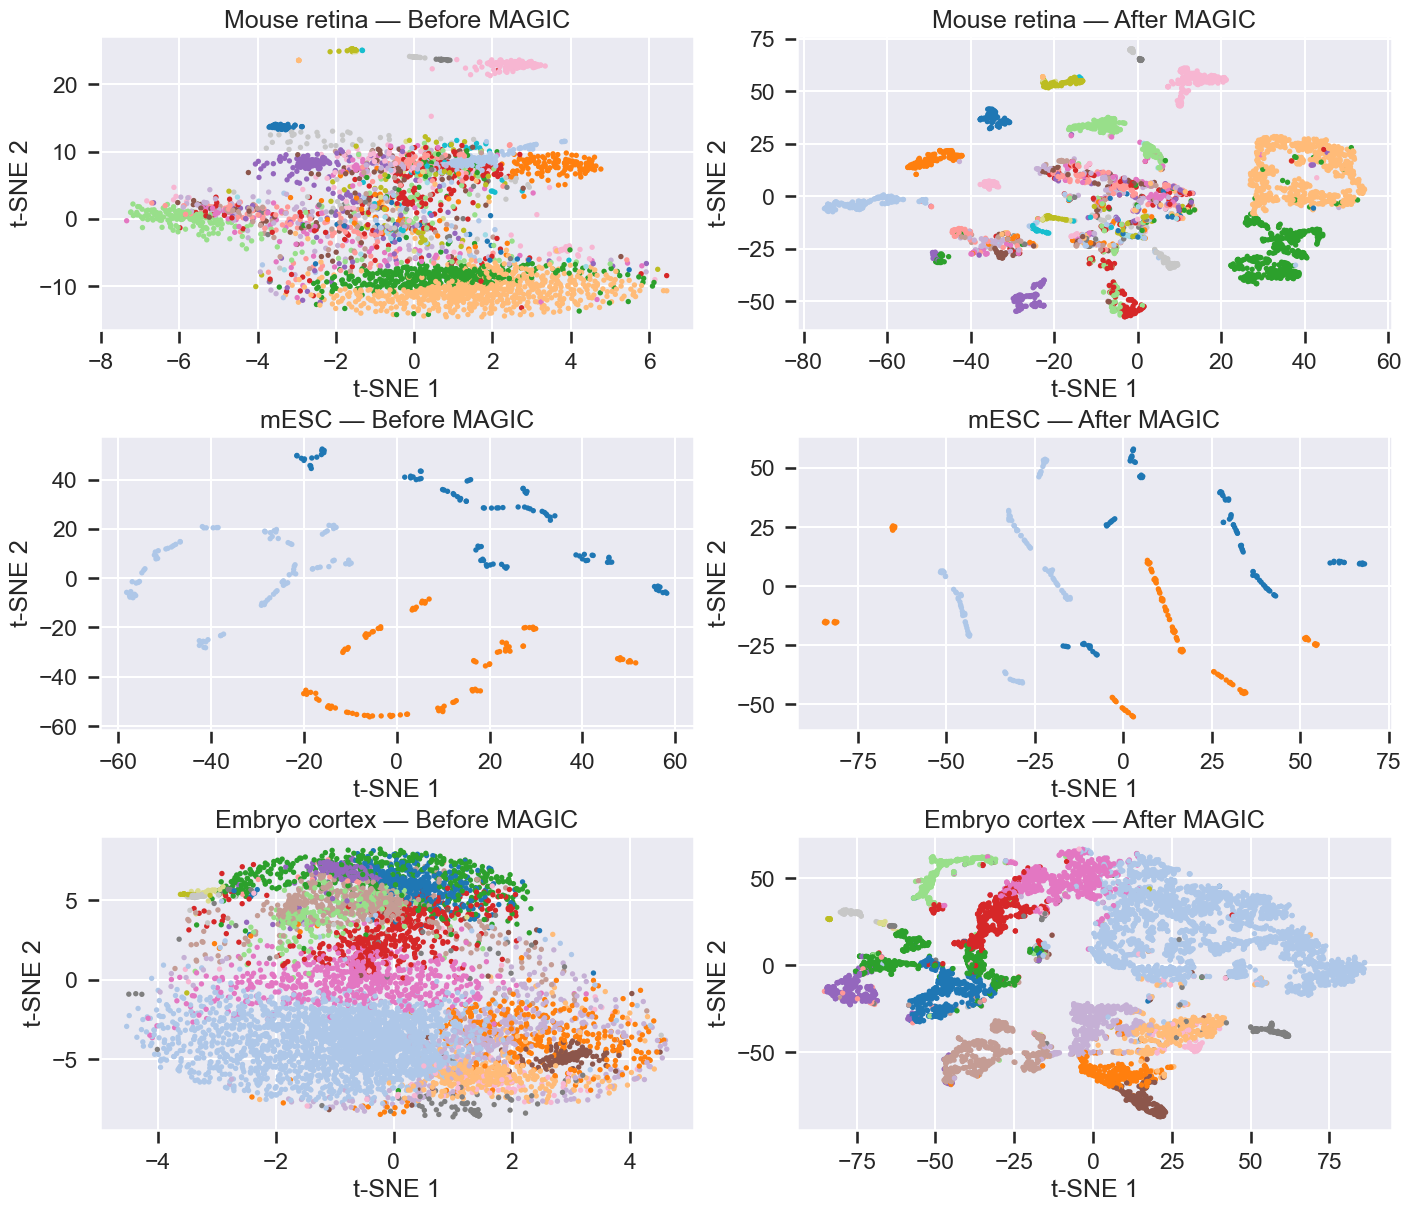

In [9]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(
    14, 4 * len(DATASETS)), constrained_layout=True)
axes = np.atleast_2d(axes)

for row, dataset_name in enumerate(DATASETS.keys()):
    for col, stage in enumerate(["Before MAGIC", "After MAGIC"]):
        ax = axes[row, col]
        subset = tsne_df[(tsne_df["dataset"] == dataset_name)
                         & (tsne_df["stage"] == stage)]
        sns.scatterplot(
            data=subset,
            x="TSNE1",
            y="TSNE2",
            hue="cluster",
            palette="tab20",
            s=15,
            linewidth=0,
            ax=ax,
            legend=False,
        )
        ax.set_title(f"{dataset_name} — {stage}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

plt.show()

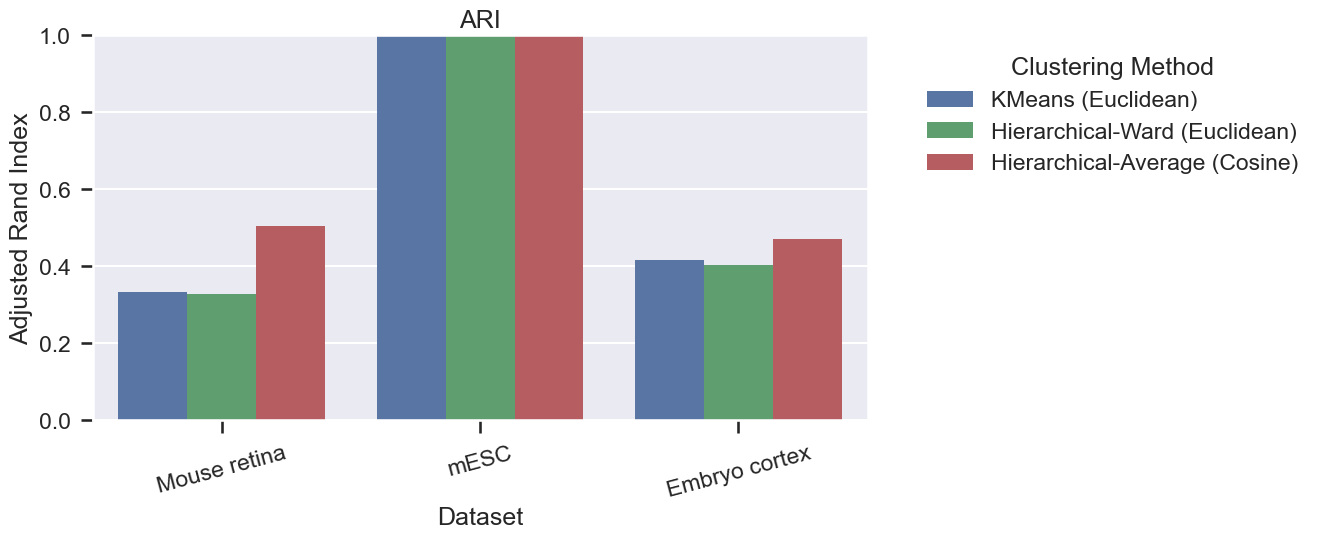

method,Hierarchical-Average (Cosine),Hierarchical-Ward (Euclidean),KMeans (Euclidean)
dataset,,,
Embryo cortex,0.470,0.403,0.417
Mouse retina,0.506,0.327,0.334
mESC,1.000,1.000,1.000


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=ari_df, x="dataset", y="ari", hue="method", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Adjusted Rand Index")
ax.set_xlabel("Dataset")
ax.set_title("ARI")
plt.xticks(rotation=15)
plt.legend(title="Clustering Method",
           bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

ari_df.pivot(index="dataset", columns="method", values="ari").round(3)

# [Optional] Discussion

Across the Retina and Embryo datasets, average-linkage hierarchical clustering with cosine distance achieves higher ARI scores than Euclidean (Ward) and KMeans, indicating that the MAGIC + PCA/UMAP feature space is better captured by angular similarity.

The ARI tables and t-SNE plots further support that cosine distance yields more compact and accurate clusters.

So: **Average linkage + cosine distance** is the best choice